In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [42]:
# Load Data
try:
    df = pd.read_csv("data/results.csv")
    df = df[df["algorithm"] != "relative_neighborhood"]
    df = df[df["k_nn"] + df["n_long"] == 25]
    df['diff'] = df['diff'].replace(-1, 20).fillna(20)
    print(f"Loaded {len(df)} rows from results.csv")
    display(df.head())
except FileNotFoundError:
    print("No results.csv found.")


Loaded 2486 rows from results.csv


,player,embedding,algorithm,k_nn,n_long,start,target,success,pth_len,opt_len,diff,path_str
1200,greedy,gemini,k_nn+n_random,0,25,madrid,manufacture,False,-1,3,20,madrid -> mill -> manual -> constructed -> cer...
1201,greedy,gemini,k_nn+n_random,0,25,religions,cellular,False,-1,3,20,religions -> functional -> foto -> pa -> auto ...
1202,greedy,gemini,k_nn+n_random,0,25,germany,pcs,False,-1,3,20,germany -> dns -> describes -> h -> ss -> edt ...
1203,greedy,gemini,k_nn+n_random,0,25,inside,bunch,False,-1,3,20,inside -> surrounded -> multi -> high -> human...
1204,greedy,gemini,k_nn+n_random,0,25,basics,metadata,False,-1,4,20,basics -> header -> embedded -> sql -> metalli...


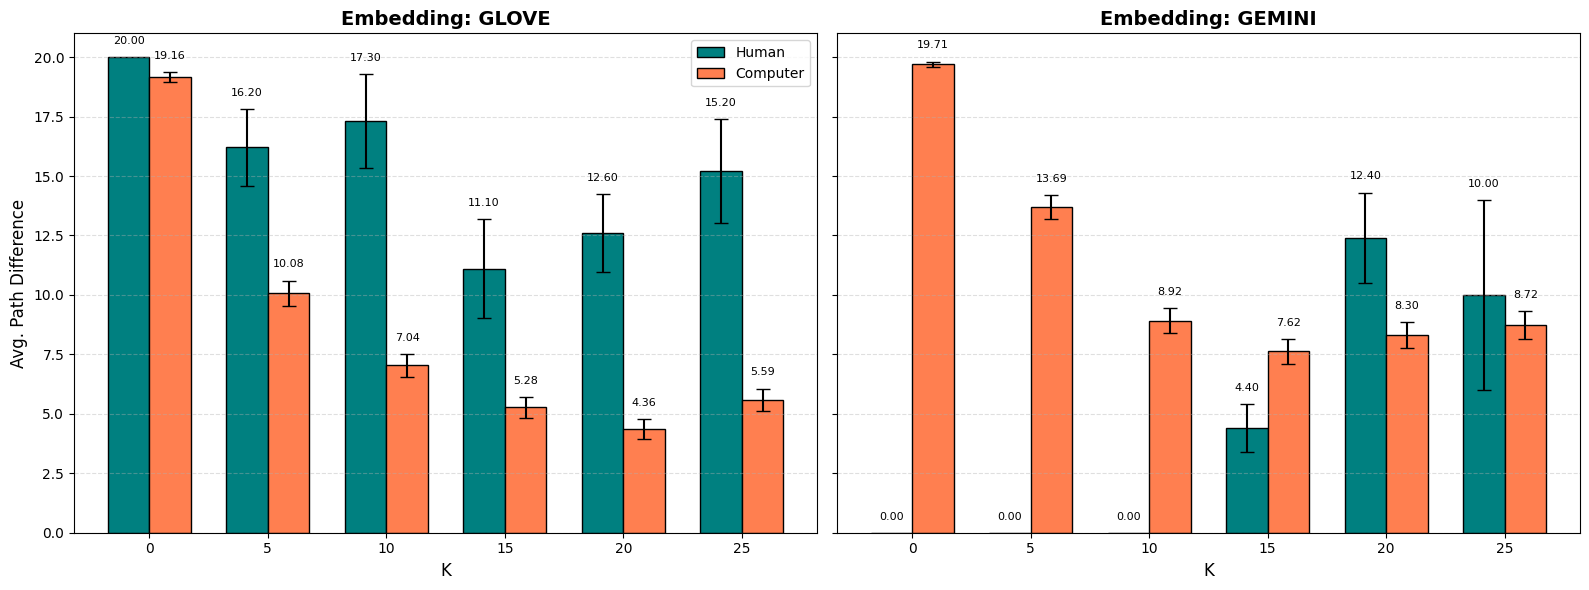

In [45]:
subset = df.copy()

# Grouping by 3 levels creates a MultiIndex: [embedding, k_nn, player]
grouped = subset.groupby(['embedding', 'k_nn', 'player'])['diff'].agg(['mean', 'sem']).unstack()

embeddings = ['glove', 'gemini']
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for i, emb in enumerate(embeddings):
    ax = axes[i]
    
    try:
        # .xs(emb) isolates 'glove' or 'gemini' and removes that level from the index
        sub_data = grouped.xs(emb, level='embedding')
        
        # Find K values where BOTH human and greedy exist to avoid alignment errors
        common_idx = sub_data['mean', 'human'].dropna().index.intersection(
                     sub_data['mean', 'greedy'].dropna().index)
        
        if not common_idx.empty:
            # Prepare data strictly for common indices
            h_mean = sub_data.loc[common_idx, ('mean', 'human')]
            h_sem  = sub_data.loc[common_idx, ('sem', 'human')]
            c_mean = sub_data.loc[common_idx, ('mean', 'greedy')]
            c_sem  = sub_data.loc[common_idx, ('sem', 'greedy')]
            
            # X positions for the bars
            x = np.arange(len(common_idx))
            width = 0.35
            
            # Plotting - Note we use the raw values now to avoid .loc confusion
            rects1 = ax.bar(x - width/2, h_mean.values, width, yerr=h_sem.values,
                            capsize=5, label='Human', color='teal', edgecolor='black')
            rects2 = ax.bar(x + width/2, c_mean.values, width, yerr=c_sem.values,
                            capsize=5, label='Computer', color='coral', edgecolor='black')
            
            # Styling
            ax.set_title(f'Embedding: {emb.upper()}', fontsize=14, fontweight='bold')
            ax.set_xticks(x)
            ax.set_xticklabels(common_idx)
            ax.set_xlabel('K', fontsize=12)
            ax.grid(True, axis='y', linestyle='--', alpha=0.4)
            
            # Labels
            ax.bar_label(rects1, padding=8, fmt='%.2f', size=8)
            ax.bar_label(rects2, padding=8, fmt='%.2f', size=8)
            
            if i == 0:
                ax.set_ylabel('Avg. Path Difference', fontsize=12)
                ax.legend()
        else:
            ax.set_title(f"{emb.upper()}: No matching Human/Computer pairs")
            
    except KeyError:
        ax.set_title(f"{emb.upper()}: Embedding not found in data")

plt.tight_layout()
plt.show()